In [ ]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import glob


sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 15,
    'savefig.dpi': 300, 
    'figure.autolayout': True
})

COLOR_PALETTE = {
    "1_Baseline": "#e8e8e8",       
    "2_LegalBERT_RAG": "#004699",  
    "3_LegalBERT_RAG_OPTIMIZED": "#ec0000"    
}

csv_path = "master_evaluatie_matrix.csv"
 
round = 16
output_map = f"figures/round_{round}"
os.makedirs(output_map, exist_ok=True)

df = pd.read_csv(csv_path)

def clean_corrupted_float(val):
    if pd.isna(val): return 0.0
    try:
        if isinstance(val, str):
            val = val.replace(",", ".")
        num = float(val)
        if num > 1.0:
            s = f"{num:.0f}"
            return float(f"0.{s[:4]}")
        return num
    except:
        return 0.0

df["Lexical_TFIDF"] = df["Lexical_TFIDF"].apply(clean_corrupted_float)
df["Semantic_BERT"] = df["Semantic_BERT"].apply(clean_corrupted_float)



C:\Users\reeuwi006\AppData\Local\Temp\ipykernel_756\1833787235.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Performance Analysis of Models in Vacation Rental and Housing Allocation", loc="lower center", bbox_to_anchor=(-0.1, -0.2), ncol=3)


Figure 1 is saved: plot_gpt_judge_scores_16.png


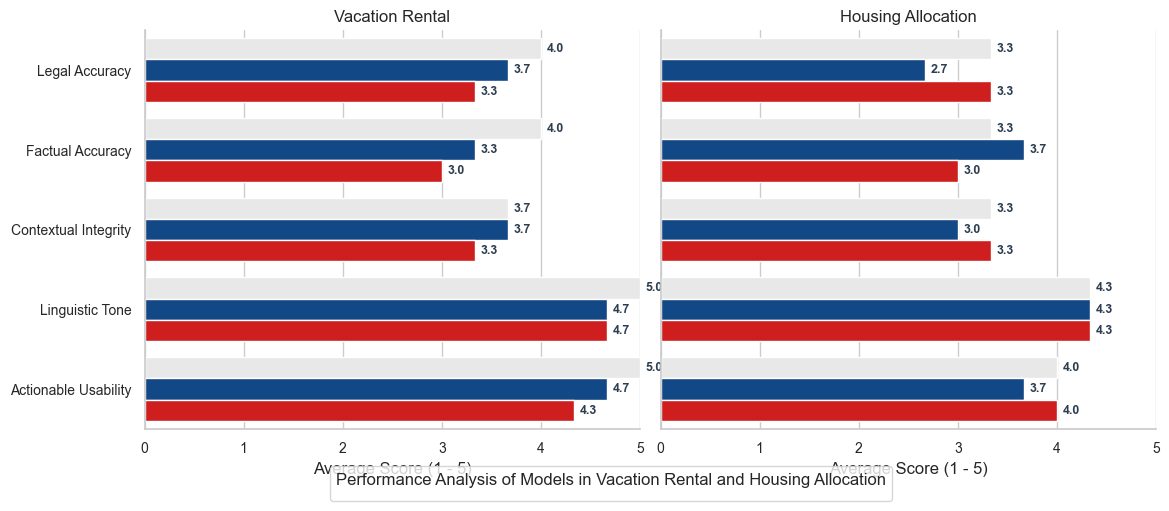

In [312]:
criteria_cols = ["JA", "FJ", "CIL", "LG", "AU"]
criteria_labels = {
    "JA": "Legal Accuracy",
    "FJ": "Factual Accuracy",
    "CIL": "Contextual Integrity",
    "LG": "Linguistic Tone",
    "AU": "Actionable Usability"
}

df_melted = df.melt(
    id_vars=["Domein", "Model"],
    value_vars=criteria_cols,
    var_name="Criterium",
    value_name="Score"
)
df_melted["Criterium_Volledig"] = df_melted["Criterium"].map(criteria_labels)

domain_labels = {
    "Vakantieverhuur": "Vacation Rental",
    "Woonruimteverdeling": "Housing Allocation" 
}
df_melted["Domein"] = df_melted["Domein"].map(domain_labels)

g = sns.catplot(
    data=df_melted,
    x="Score",
    y="Criterium_Volledig",
    hue="Model",
    col="Domein",
    kind="bar",
    palette=COLOR_PALETTE,
    errorbar=None,
    height=5,
    aspect=1.2,
    legend=False
)

g.set_titles("{col_name}")
g.set_axis_labels("Average Score (1 - 5)", "") 

for ax in g.axes.flat:
    ax.set_xlim(0, 5)
    ax.set_xticks(range(6))
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(f"{width:.1f}", 
                        (width, p.get_y() + p.get_height() / 2.), 
                        ha='left', va='center', 
                        xytext=(4, 0), 
                        textcoords='offset points',
                        fontsize=9, color='#2c3e50', weight='bold')

plt.legend(title="Performance Analysis of Models in Vacation Rental and Housing Allocation", loc="lower center", bbox_to_anchor=(-0.1, -0.2), ncol=3)

g.savefig(f"{output_map}/plot_gpt_judge_scores_{round}.png", bbox_inches='tight')
print(f"Figure 1 is saved: plot_gpt_judge_scores_{round}.png")

Figure 2 is saved: plot_similarity_metrics_16.png


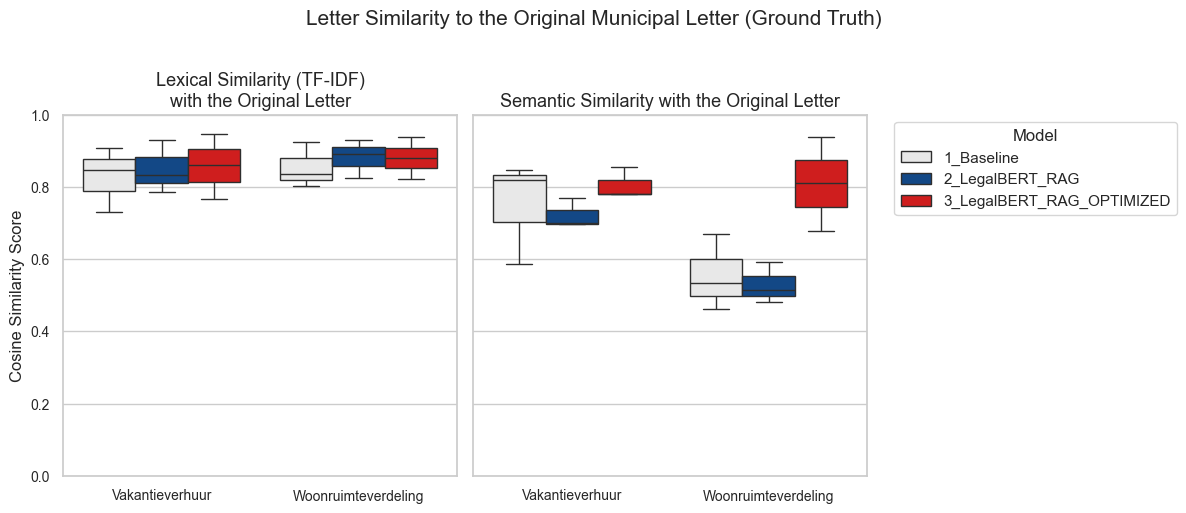

In [313]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.boxplot(
    data=df,
    x="Domein",
    y="Lexical_TFIDF",
    hue="Model",
    palette=COLOR_PALETTE,
    ax=axes[0]
)
axes[0].set_title("Lexical Similarity (TF-IDF)\nwith the Original Letter")
axes[0].set_ylabel("Cosine Similarity Score")
axes[0].set_xlabel("")
axes[0].get_legend().remove()

sns.boxplot(
    data=df,
    x="Domein",
    y="Semantic_BERT",
    hue="Model",
    palette=COLOR_PALETTE,
    ax=axes[1]
)
axes[1].set_title("Semantic Similarity with the Original Letter")
axes[1].set_ylabel("")
axes[1].set_xlabel("")
axes[1].legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')

for ax in axes:
    ax.set_ylim(0, 1)

plt.suptitle("Letter Similarity to the Original Municipal Letter (Ground Truth)", y=1.02)
plt.savefig(f"{output_map}/plot_similarity_metrics_{round}.png", bbox_inches='tight')
print(f"Figure 2 is saved: plot_similarity_metrics_{round}.png")

Figure 3 is saved: plot_word_count_comparison_16.png


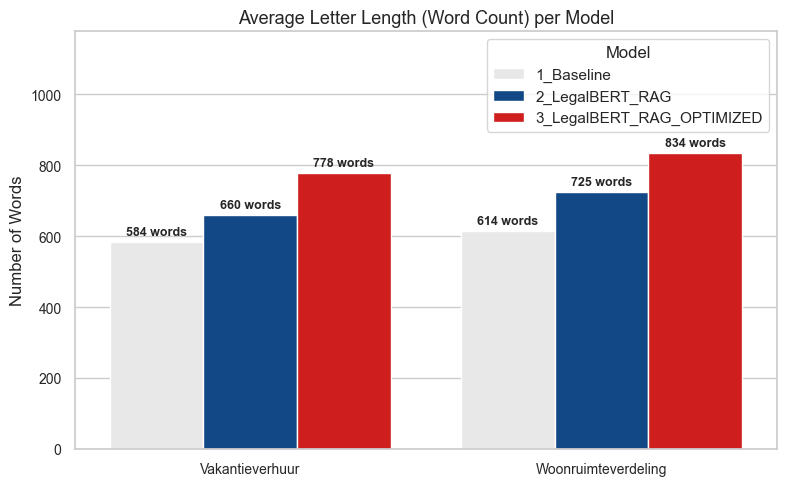

In [314]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df,
    x="Domein",
    y="Word_Count",
    hue="Model",
    palette=COLOR_PALETTE,
    errorbar=None
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:.0f} words",
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    xytext=(0, 3),
                    textcoords='offset points',
                    fontsize=9, weight='bold')

plt.title("Average Letter Length (Word Count) per Model")
plt.ylabel("Number of Words")
plt.xlabel("")
plt.ylim(0, df["Word_Count"].max() * 1.15)
plt.legend(title="Model", loc="upper right")
plt.savefig(f"{output_map}/plot_word_count_comparison_{round}.png", bbox_inches='tight')
print(f"Figure 3 is saved: plot_word_count_comparison_{round}.png")

Figure 4 is saved: plot_quality_quantity_paradox_16.png


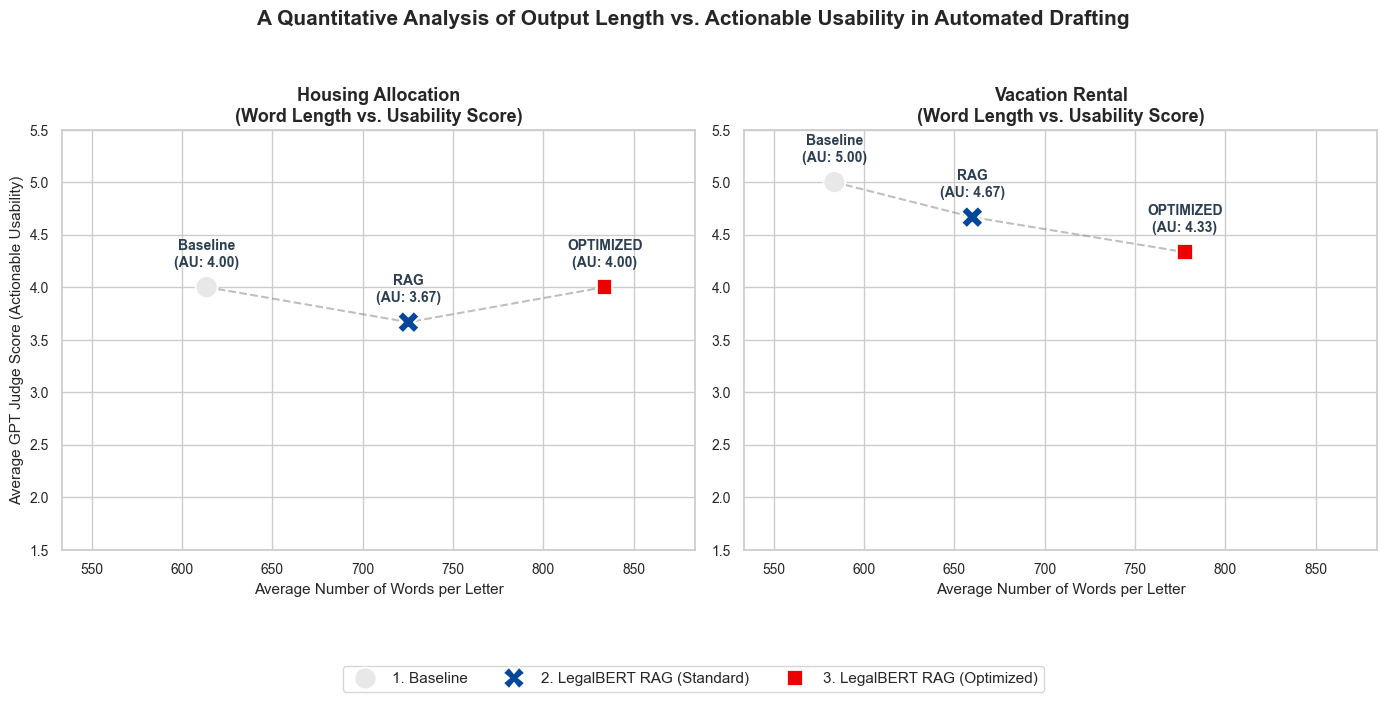

In [ ]:

domain_labels = {
    "Vakantieverhuur": "Vacation Rental",
    "Woonruimteverdeling": "Housing Allocation" 
}
df["Domein"] = df["Domein"].map(domain_labels).fillna(df["Domein"])

df_stats = df.groupby(["Domein", "Model"]).agg({
    "Word_Count": "mean",
    "AU": "mean",
    "JA": "mean",
    "Semantic_BERT": "mean"
}).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

domeinen = df_stats["Domein"].unique()

for i, domein in enumerate(domeinen):
    df_dom = df_stats[df_stats["Domein"] == domein]
    ax = axes[i]
    
    df_dom_sorted = df_dom.sort_values("Model")
    ax.plot(df_dom_sorted["Word_Count"], df_dom_sorted["AU"], color="gray", linestyle="--", alpha=0.5, zorder=1)
    
    sns.scatterplot(
        data=df_dom,
        x="Word_Count",
        y="AU",
        hue="Model",
        style="Model",
        palette=COLOR_PALETTE,
        s=250,
        ax=ax,
        zorder=2
    )
    
    for _, row in df_dom.iterrows():
        model_label = row["Model"].split("_")[-1]
        ax.annotate(f"{model_label}\n(AU: {row['AU']:.2f})", 
                    (row["Word_Count"], row["AU"]),
                    textcoords="offset points", 
                    xytext=(0, 15), 
                    ha='center', 
                    fontsize=10, 
                    weight='bold',
                    color='#2c3e50')
        
    ax.set_title(f"{domein}\n(Word Length vs. Usability Score)", fontsize=13, weight='bold')
    ax.set_xlabel("Average Number of Words per Letter", fontsize=11)
    if i == 0:
        ax.set_ylabel("Average GPT Judge Score (Actionable Usability)", fontsize=11)
    else:
        ax.set_ylabel("")
        
    ax.set_xlim(df_stats["Word_Count"].min() - 50, df_stats["Word_Count"].max() + 50)
    
    ax.set_ylim(1.5, 5.5) 
    
    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ["1. Baseline", "2. LegalBERT RAG (Standard)", "3. LegalBERT RAG (Optimized)"], 
           loc="lower center", bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=11)

plt.suptitle("A Quantitative Analysis of Output Length vs. Actionable Usability in Automated Drafting", y=1.05, fontsize=15, weight='bold')

plt.tight_layout()
fig.subplots_adjust(top=0.85, bottom=0.15) 

plt.savefig(f"{output_map}/plot_quality_quantity_paradox_{round}.png", bbox_inches='tight', dpi=300)
print(f"Figure 4 is saved: plot_quality_quantity_paradox_{round}.png")

In [316]:


print("DETAILED QUALITATIVE AUDIT PER EVALUATED CASE")
print("-" * 90)

def print_indented(label, text, width=95, indent=6):
    prefix = " " * indent
    lines = textwrap.wrap(str(text), width=width)
    print(f"{prefix[:-3]}{label}:")
    for line in lines:
        print(f"{prefix}{line}")

domain_labels = {
    "Vakantieverhuur": "Vacation Rental",
    "Woonruimteverdeling": "Housing Allocation" 
}
df["Domein"] = df["Domein"].map(domain_labels).fillna(df["Domein"])

for (domain, case_id), group in df.groupby(["Domein", "Zaak_ID"]):
    print(f"\nDOMAIN: {domain} | CASE ID: {case_id}")
    print("-" * 90)
    
    for _, row in group.sort_values("Model").iterrows():
        print(f"Model: {row['Model']}")
        
        motivation = row.get("Motivatie", "")
        drawbacks = row.get("Geconstateerde_Nadelen", "")
        alignment = row.get("Best_Model_Alignment", "")
        
        print_indented("Motivation", motivation)
        print_indented("Identified Drawbacks", drawbacks)
        print_indented("Amsterdam Feedback Alignment", alignment)
        print()
        
    print("-" * 90)

DETAILED QUALITATIVE AUDIT PER EVALUATED CASE
------------------------------------------------------------------------------------------

DOMAIN: Housing Allocation | CASE ID: WO.23.004695.001
------------------------------------------------------------------------------------------
Model: 1_Baseline
   Motivation:
      The generated letter demonstrates flawless legal accuracy (JA) and factual correctness (FJ), as
      it correctly applies the relevant laws (HVV 2.5.2) and includes all critical dossier details
      (dates, arguments, and decision). The contextual integrity (CIL) is strong but slightly
      weakened by a lack of deeper engagement with the citizen's specific arguments, such as the
      teleological interpretation of 'gezamenlijke woning.' Linguistically (LG), the letter is clear,
      concise, and citizen-friendly, avoiding unnecessary legal jargon. Usability (AU) is excellent,
      as the letter achieves the same legal outcome as the reference while being signifi

In [331]:
print("\n" + "-" * 50)
print("AVERAGE SCORES AND WORD COUNT FOR THESIS TABLE")
print("-" * 50)

summary = df.groupby(["Domein", "Model"])[["Word_Count", "JA", "FJ", "CIL", "LG", "AU", "Lexical_TFIDF", "Semantic_BERT"]].mean().round(2)

print(summary.to_string())

summary.to_csv(f"summary/summary_scores_thesis_{round}.csv")
try:
    summary.to_excel(f"summary/summary_scores_thesis_{round}.xlsx")
    print("\nSuccessfully saved to disk as:")
    print(f"   - summary/summary_scores_thesis_{round}.csv")
    print(f"   - summary/summary_scores_thesis_{round}.xlsx")
except ImportError:
    print("\nSuccessfully saved to disk as:")
    print(f"   - summary/summary_scores_thesis_{round}.csv (Excel export skipped due to missing library)")

summary.to_clipboard(excel=True, sep='\t')

print("-" * 50)
print("The table has also been automatically copied! Go to Excel and press CTRL+V.")
print("-" * 50)


--------------------------------------------------
AVERAGE SCORES AND WORD COUNT FOR THESIS TABLE
--------------------------------------------------
                                              Word_Count    JA    FJ   CIL    LG    AU  Lexical_TFIDF  Semantic_BERT
Domein             Model                                                                                            
Housing Allocation 1_Baseline                     613.67  3.33  3.33  3.33  4.33  4.00           0.85           0.56
                   2_LegalBERT_RAG                725.33  2.67  3.67  3.00  4.33  3.67           0.88           0.53
                   3_LegalBERT_RAG_OPTIMIZED      834.00  3.33  3.00  3.33  4.33  4.00           0.88           0.81
Vacation Rental    1_Baseline                     583.67  4.00  4.00  3.67  5.00  5.00           0.83           0.75
                   2_LegalBERT_RAG                660.00  3.67  3.33  3.67  4.67  4.67           0.85           0.72
                   3_LegalBERT_

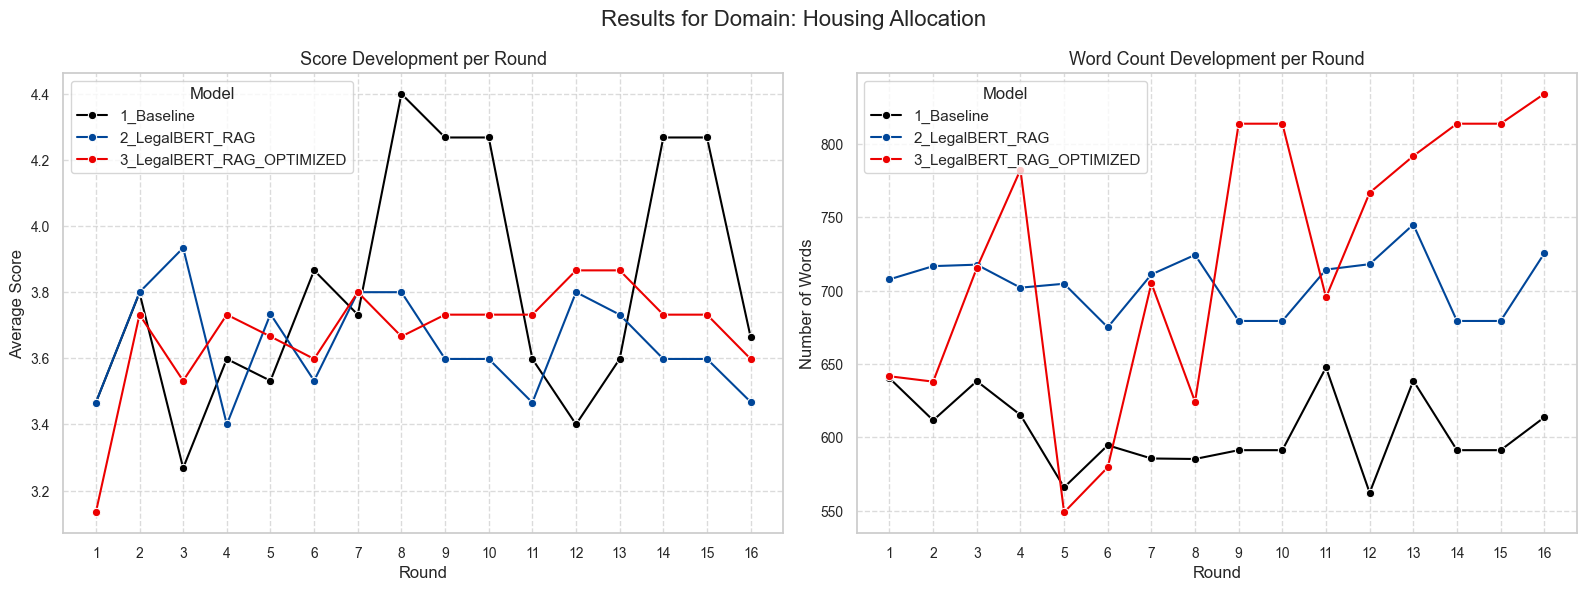

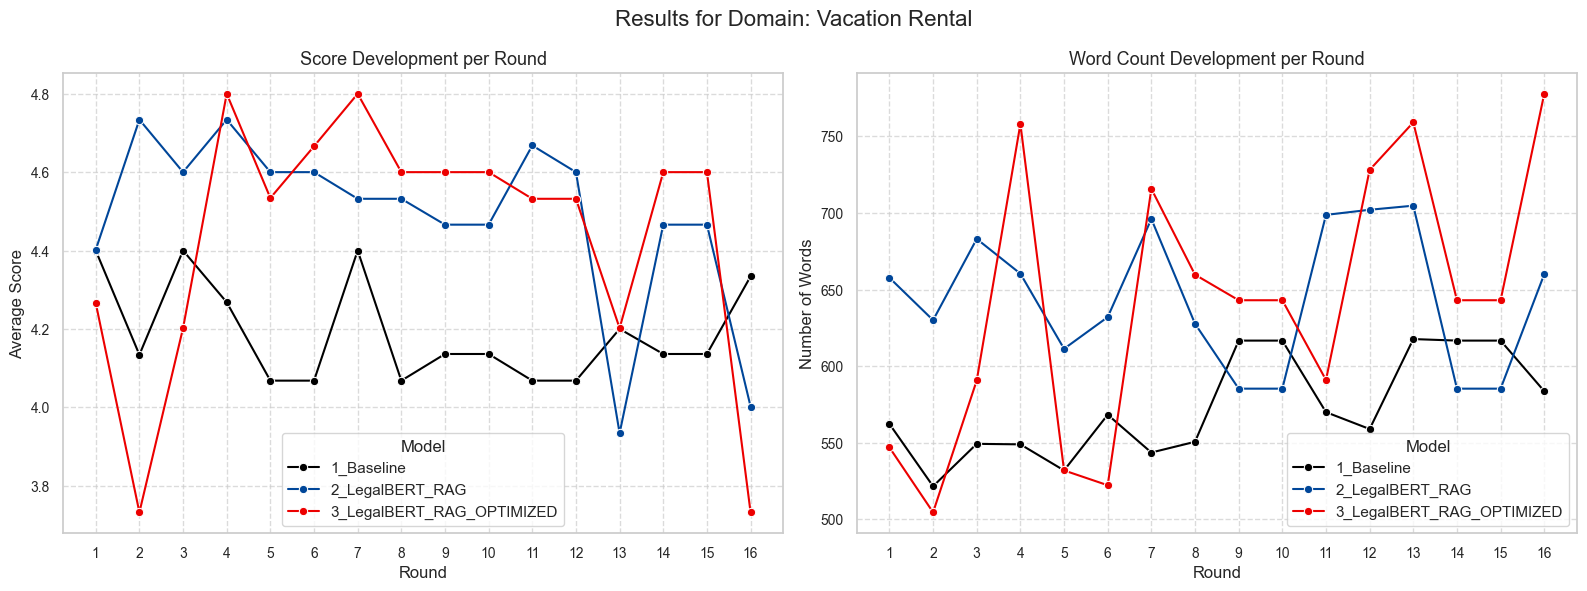

In [318]:
folder_path = 'summary' 
files = glob.glob(os.path.join(folder_path, 'summary_scores_thesis_*.csv')) 

all_data = []

for file in files:
    df_temp = pd.read_csv(file) 
    
    match = re.search(r'_(\d+)\.csv$', file)
    round_num = int(match.group(1)) if match else 0
    if round_num == 0:
        continue
        
    df_temp['Round'] = round_num
    all_data.append(df_temp)

combined_df = pd.concat(all_data, ignore_index=True)

domain_labels = {
    "Vakantieverhuur": "Vacation Rental",
    "Woonruimteverdeling": "Housing Allocation" 
}
if 'Domein' in combined_df.columns:
    combined_df['Domain'] = combined_df['Domein'].map(domain_labels).fillna(combined_df['Domein'])
elif 'Domain' in combined_df.columns:
    combined_df['Domain'] = combined_df['Domain'].map(domain_labels).fillna(combined_df['Domain'])

combined_df['Score'] = combined_df[['JA', 'FJ', 'CIL', 'LG', 'AU']].mean(axis=1)

COLOR_PALETTE = {
    "1_Baseline": "#000000",       
    "2_LegalBERT_RAG": "#004699",  
    "3_LegalBERT_RAG_OPTIMIZED": "#ec0000"    
}

word_count_col = 'Word_Count'
domains = combined_df['Domain'].unique()

for domain in domains:
    df_domain = combined_df[combined_df['Domain'] == domain]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Results for Domain: {domain}', fontsize=16)

    sns.lineplot(data=df_domain, x='Round', y='Score', hue='Model', palette=COLOR_PALETTE, marker='o', ax=ax1)
    ax1.set_title('Score Development per Round')
    ax1.set_xlabel('Round')
    ax1.set_ylabel('Average Score')
    ax1.set_xticks(sorted(df_domain['Round'].unique())) 
    ax1.grid(True, linestyle='--', alpha=0.7)

    sns.lineplot(data=df_domain, x='Round', y=word_count_col, hue='Model', palette=COLOR_PALETTE, marker='o', ax=ax2)
    ax2.set_title('Word Count Development per Round')
    ax2.set_xlabel('Round')
    ax2.set_ylabel('Number of Words')
    ax2.set_xticks(sorted(df_domain['Round'].unique()))
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    
    os.makedirs("figures", exist_ok=True)
    plt.savefig(f"figures/total_results_{domain.lower().replace(' ', '_')}.png", bbox_inches='tight', dpi=300)
    plt.show()

    combined_df.to_csv(f"summary/totall_score_after_{round}_round(s).csv")

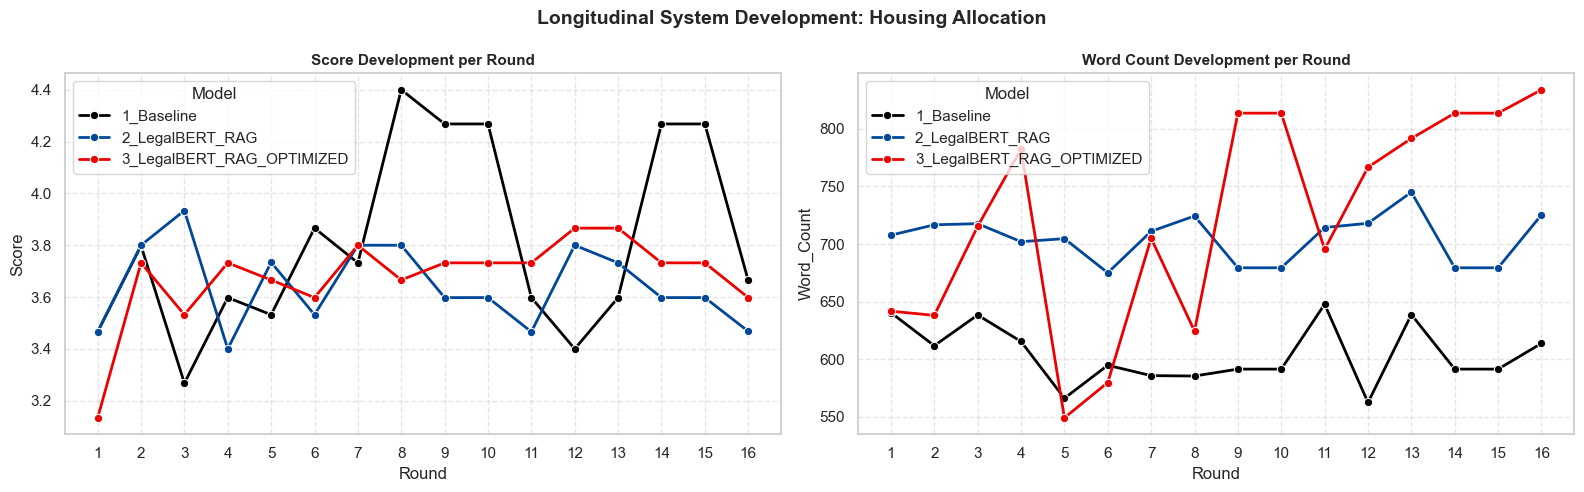

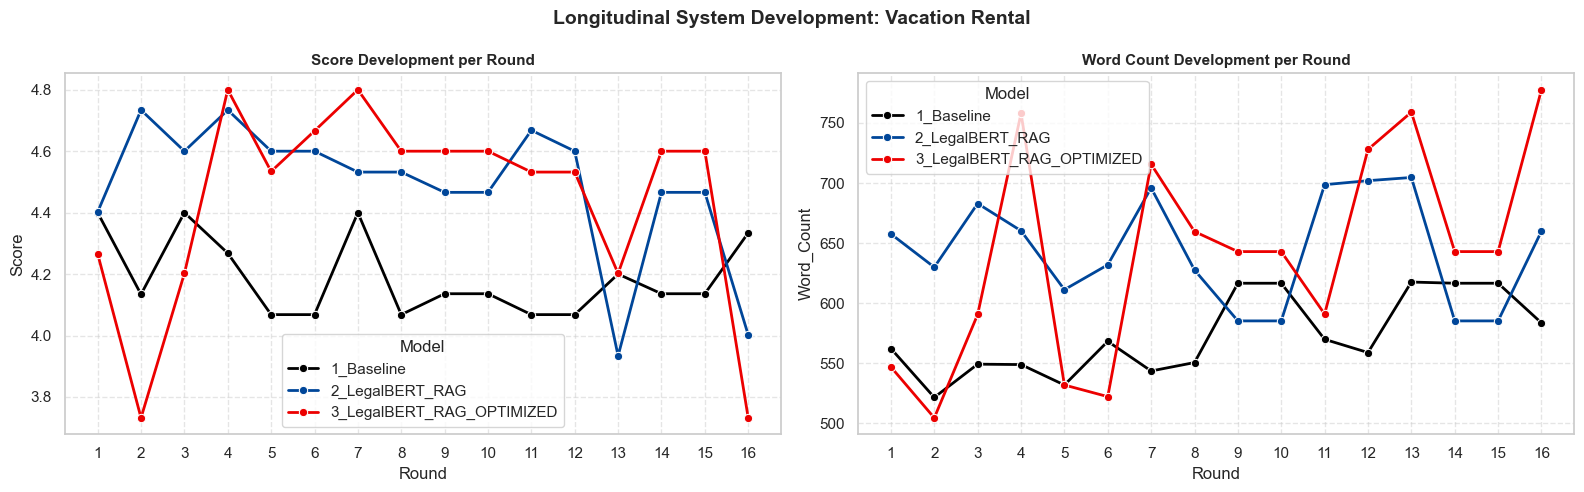

In [332]:

df_total = pd.read_csv("summary/totall_score_after_16_round(s).csv")
if 'Domain' not in df_total.columns and 'Domein' in df_total.columns:
    df_total['Domain'] = df_total['Domein']

COLOR_PALETTE = {"1_Baseline": "#000000", "2_LegalBERT_RAG": "#004699", "3_LegalBERT_RAG_OPTIMIZED": "#ec0000"}

for domain in df_total['Domain'].unique():
    df_domain = df_total[df_total['Domain'] == domain]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'Longitudinal System Development: {domain}', fontsize=14, weight='bold')

    # Left: Score Trend
    sns.lineplot(data=df_domain, x='Round', y='Score', hue='Model', palette=COLOR_PALETTE, marker='o', ax=ax1, linewidth=2)
    ax1.set_title('Score Development per Round', fontsize=11, weight='bold')
    ax1.set_xticks(sorted(df_domain['Round'].unique()))
    ax1.grid(True, linestyle='--', alpha=0.5)

    # Right: Word Count Trend
    sns.lineplot(data=df_domain, x='Round', y='Word_Count', hue='Model', palette=COLOR_PALETTE, marker='o', ax=ax2, linewidth=2)
    ax2.set_title('Word Count Development per Round', fontsize=11, weight='bold')
    ax2.set_xticks(sorted(df_domain['Round'].unique()))
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig(f"figures/trends_{domain.lower().replace(' ', '_')}.png", bbox_inches='tight', dpi=300)
    plt.show()

0     3.165
1     3.165
2     2.500
3     4.000
4     4.335
5     3.665
6     4.000
7     3.165
8     3.165
9     3.835
10    4.165
11    4.500
12    3.330
13    2.835
14    3.165
15    3.665
16    4.670
17    4.330
18    3.000
19    3.670
Name: Safety_Score, dtype: float64


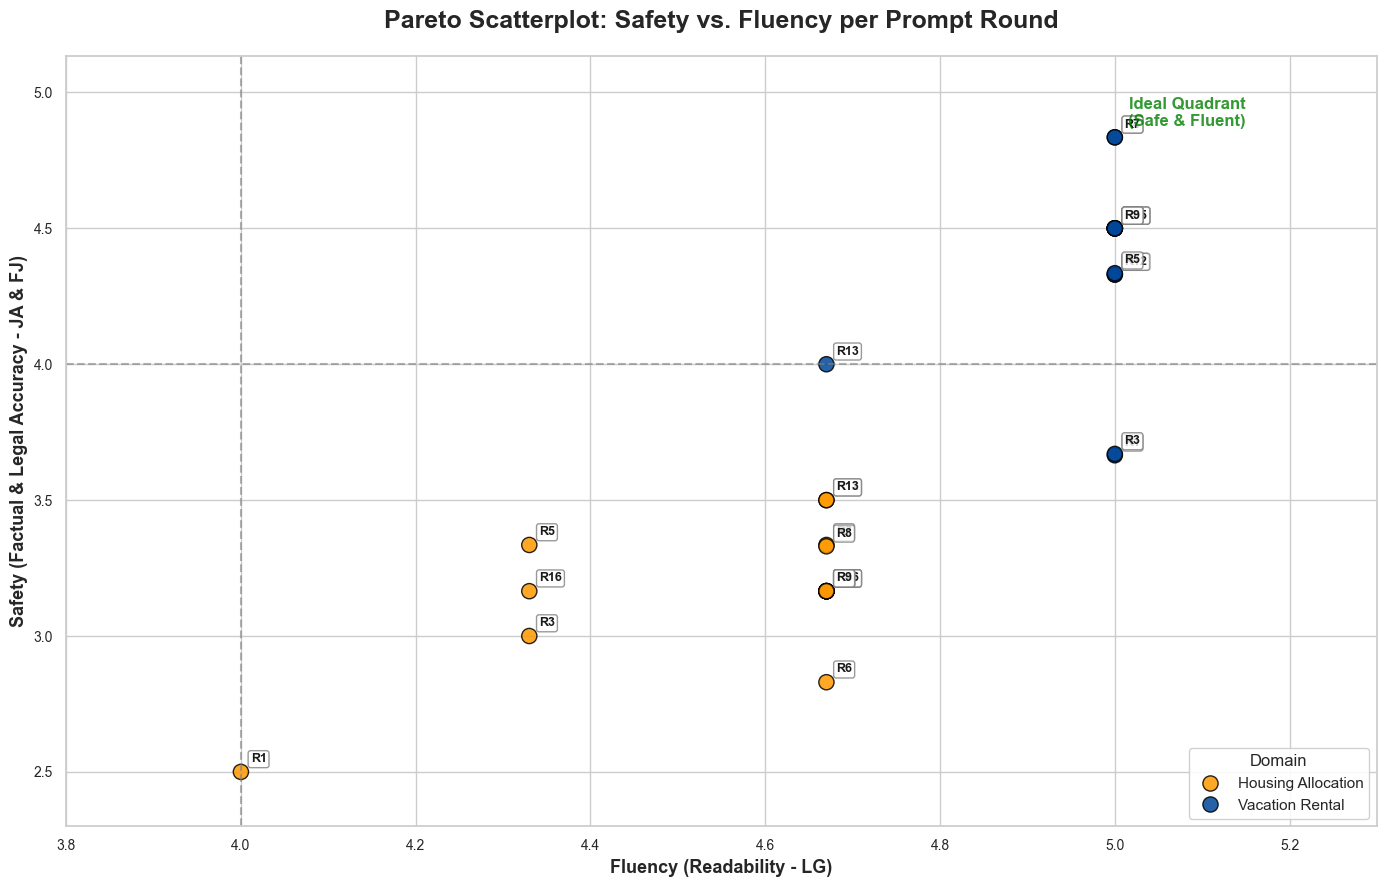

In [ ]:

combined_df['Safety_Score'] = combined_df[['JA', 'FJ']].mean(axis=1)
print(combined_df['Safety_Score'][:20])
combined_df['Fluency_Score'] = combined_df['LG']

df_opt = combined_df[combined_df['Model'] == '3_LegalBERT_RAG_OPTIMIZED'].copy()

plt.figure(figsize=(14, 9))
sns.set_style("whitegrid") 

unique_domains = df_opt['Domain'].unique()

domain_colors = {}
for domain in unique_domains:
    if "Vacation" in domain:
        domain_colors[domain] = "#004699" 
    else:
        domain_colors[domain] = "#ff9900" 

sns.scatterplot(
    data=df_opt, 
    x='Fluency_Score', 
    y='Safety_Score', 
    hue='Domain', 
    palette=domain_colors,
    s=120, 
    alpha=0.85,
    edgecolor='black',
    linewidth=1
)

for i in range(len(df_opt)):
    plt.annotate(
        f"R{df_opt['Round'].iloc[i]}", 
        (df_opt['Fluency_Score'].iloc[i], df_opt['Safety_Score'].iloc[i]),
        xytext=(7, 7),
        textcoords='offset points',
        fontsize=9,
        fontweight='bold',
        color='#1a1a1a',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8) 
    )

plt.title('Pareto Scatterplot: Safety vs. Fluency per Prompt Round', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Fluency (Readability - LG)', fontsize=13, fontweight='bold')
plt.ylabel('Safety (Factual & Legal Accuracy - JA & FJ)', fontsize=13, fontweight='bold')

plt.xlim(df_opt['Fluency_Score'].min() - 0.2, df_opt['Fluency_Score'].max() + 0.3)
plt.ylim(df_opt['Safety_Score'].min() - 0.2, df_opt['Safety_Score'].max() + 0.3)

plt.axvline(x=4.0, color='gray', linestyle='--', alpha=0.6)
plt.axhline(y=4.0, color='gray', linestyle='--', alpha=0.6)

plt.text(
    x=df_opt['Fluency_Score'].max() + 0.15, 
    y=df_opt['Safety_Score'].max() + 0.15, 
    s='Ideal Quadrant\n(Safe & Fluent)', 
    color='green', 
    fontsize=12, 
    fontweight='bold', 
    alpha=0.8,
    ha='right',
    va='top'
)

plt.legend(title='Domain', fontsize=11, title_fontsize=12, loc='lower right', framealpha=0.9)
plt.tight_layout()

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/pareto_scatterplot_safety_vs_fluency.png", bbox_inches='tight', dpi=300)
plt.show()

C:\Users\reeuwi006\AppData\Local\Temp\ipykernel_756\1938953817.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["1. Baseline", "2. LegalBERT RAG", "3. Optimized RAG"], weight='bold', fontsize=9)


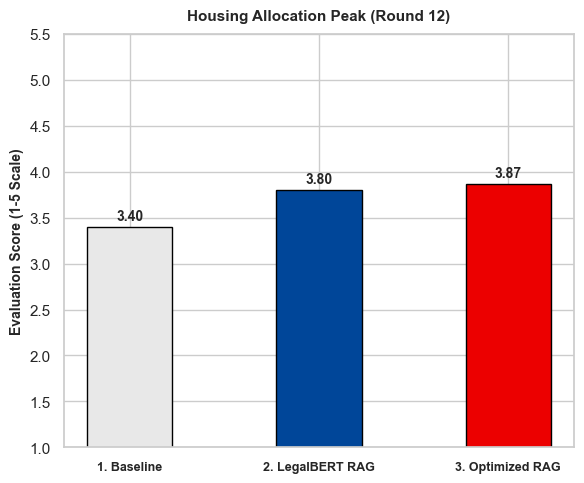

Saved independent figure to: figures/peak_snapshot_housing_allocation.png


C:\Users\reeuwi006\AppData\Local\Temp\ipykernel_756\1938953817.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["1. Baseline", "2. LegalBERT RAG", "3. Optimized RAG"], weight='bold', fontsize=9)


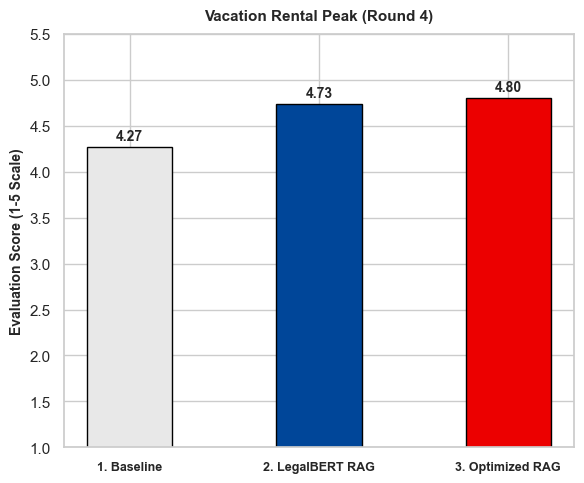

Saved independent figure to: figures/peak_snapshot_vacation_rental.png


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "summary/totall_score_after_16_round(s).csv"
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Bestand niet gevonden! Gezocht naar: {file_path}")

df_total = pd.read_csv(file_path)

if 'Domain' not in df_total.columns and 'Domein' in df_total.columns:
    df_total['Domain'] = df_total['Domein']

COLOR_PALETTE = {
    "1_Baseline": "#e8e8e8",       
    "2_LegalBERT_RAG": "#004699",  
    "3_LegalBERT_RAG_OPTIMIZED": "#ec0000"    
}
sns.set_theme(style="whitegrid")

df_optimized = df_total[df_total["Model"] == "3_LegalBERT_RAG_OPTIMIZED"]
peak_optimized_indices = df_optimized.groupby("Domain")["Score"].idxmax()

os.makedirs("figures", exist_ok=True)

for idx in peak_optimized_indices:
    peak_row = df_total.loc[idx]
    current_domain = peak_row["Domain"]
    peak_round = peak_row["Round"]
    
    df_round_compare = df_total[(df_total["Domain"] == current_domain) & (df_total["Round"] == peak_round)].sort_values("Model")
    
    fig, ax = plt.subplots(figsize=(6, 5))
    
    bars = ax.bar(df_round_compare["Model"], df_round_compare["Score"], 
                  color=[COLOR_PALETTE[m] for m in df_round_compare["Model"]], edgecolor='black', width=0.45)
    
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', weight='bold', fontsize=10)
        
    ax.set_title(f"{current_domain} Peak (Round {int(peak_round)})", fontsize=11, weight='bold', pad=10)
    ax.set_ylabel("Evaluation Score (1-5 Scale)", weight='bold', fontsize=10)
    ax.set_xlabel("")
    ax.set_ylim(1.0, 5.5)
    ax.set_xticklabels(["1. Baseline", "2. LegalBERT RAG", "3. Optimized RAG"], weight='bold', fontsize=9)
    
    safe_filename = current_domain.lower().replace(" ", "_")
    output_path = f"figures/peak_snapshot_{safe_filename}.png"
    
    plt.tight_layout()
    plt.savefig(output_path, bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()
    print(f"Saved independent figure to: {output_path}")

C:\Users\reeuwi006\AppData\Local\Temp\ipykernel_756\2085675752.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, weight='bold', fontsize=11)


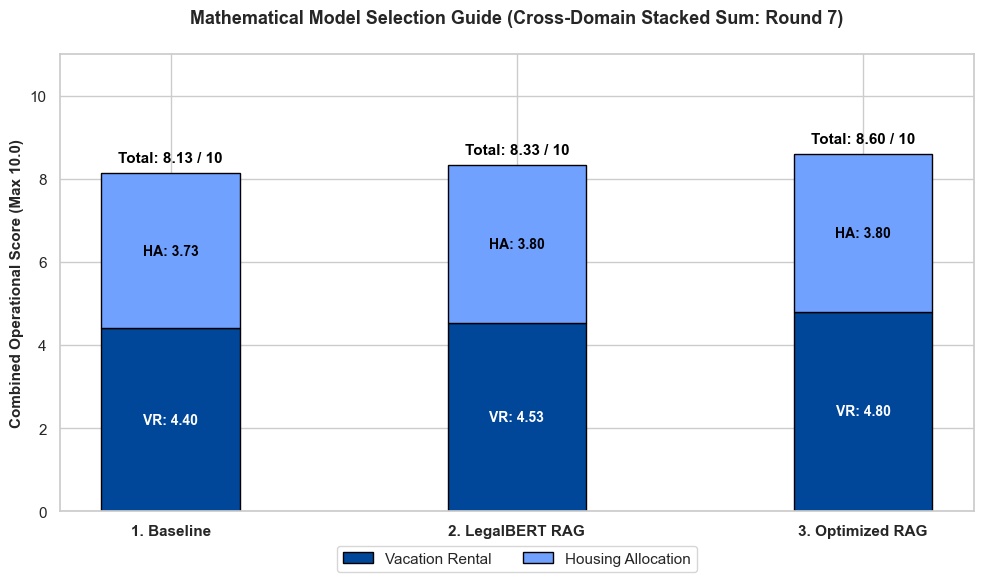

In [ ]:
file_path = "summary/totall_score_after_16_round(s).csv"

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Bestand niet gevonden! Gezocht naar: {file_path}")

df_total = pd.read_csv(file_path)

if 'Domain' not in df_total.columns and 'Domein' in df_total.columns:
    df_total['Domain'] = df_total['Domein']

df_domain_split = df_total.groupby(["Round", "Model", "Domain"])["Score"].sum().unstack(level="Domain").reset_index()

df_domain_split["Total_Score"] = df_domain_split["Housing Allocation"] + df_domain_split["Vacation Rental"]

best_overall_row = df_domain_split.loc[df_domain_split["Total_Score"].idxmax()]
best_round = best_overall_row["Round"]

df_best_round = df_domain_split[df_domain_split["Round"] == best_round].sort_values("Model")

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

COLOR_VR = "#004699"         
COLOR_HA = "#70a1ff"          
models = ["1. Baseline", "2. LegalBERT RAG", "3. Optimized RAG"]

bars_vr = ax.bar(df_best_round["Model"], df_best_round["Vacation Rental"], 
                 color=COLOR_VR, edgecolor='black', width=0.4, label="Vacation Rental")

bars_ha = ax.bar(df_best_round["Model"], df_best_round["Housing Allocation"], 
                 bottom=df_best_round["Vacation Rental"], 
                 color=COLOR_HA, edgecolor='black', width=0.4, label="Housing Allocation")

for idx, (_, row) in enumerate(df_best_round.iterrows()):
    vr_val = row["Vacation Rental"]
    ha_val = row["Housing Allocation"]
    total_val = row["Total_Score"]

    ax.annotate(f"VR: {vr_val:.2f}",
                xy=(idx, vr_val / 2),
                ha='center', va='center', color='white', weight='bold', fontsize=10)
    
    ax.annotate(f"HA: {ha_val:.2f}",
                xy=(idx, vr_val + (ha_val / 2)),
                ha='center', va='center', color='black', weight='bold', fontsize=10)
    
    ax.annotate(f"Total: {total_val:.2f} / 10",
                xy=(idx, total_val),
                xytext=(0, 6),  
                textcoords="offset points",
                ha='center', va='bottom', weight='bold', fontsize=11, color='black')

ax.set_title(f"Mathematical Model Selection Guide (Cross-Domain Stacked Sum: Round {int(best_round)})", 
             fontsize=13, weight='bold', y=1.05)
ax.set_ylabel("Combined Operational Score (Max 10.0)", fontsize=11, weight='bold')
ax.set_xlabel("")
ax.set_ylim(0.0, 11.0)  
ax.set_xticklabels(models, weight='bold', fontsize=11)

ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=11)

plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/mathematical_model_selection_guide_stacked.png", bbox_inches='tight', dpi=300)
plt.show()

C:\Users\reeuwi006\AppData\Local\Temp\ipykernel_756\641144701.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Vacation Rental", "Housing Allocation"])


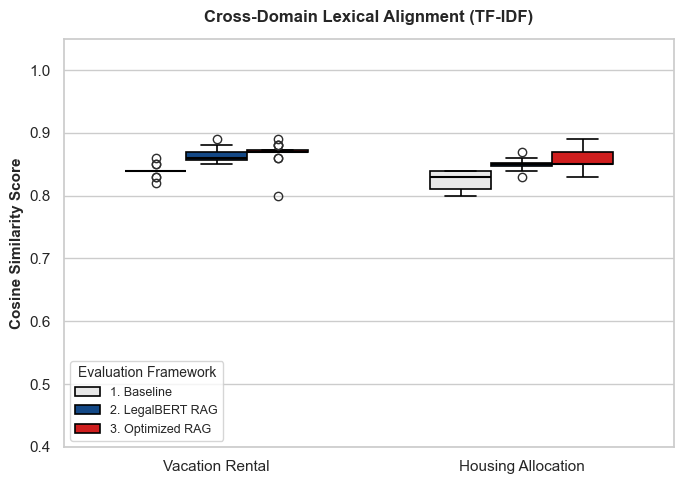

C:\Users\reeuwi006\AppData\Local\Temp\ipykernel_756\641144701.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Vacation Rental", "Housing Allocation"])


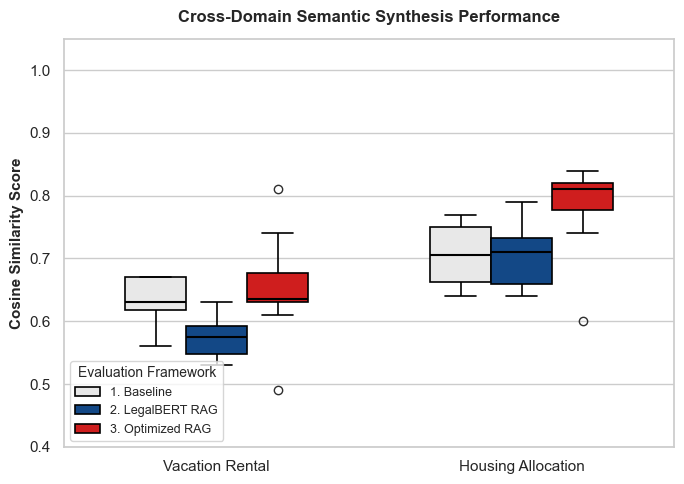

In [352]:
file_path = "summary/totall_score_after_16_round(s).csv"
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Bestand niet gevonden! Gezocht naar: {file_path}")

df_total = pd.read_csv(file_path)

if 'Domain' not in df_total.columns and 'Domein' in df_total.columns:
    df_total['Domain'] = df_total['Domein']

df_total['Domain'] = df_total['Domain'].replace({
    "Vakantieverhuur": "Vacation Rental",
    "Woonruimteverdeling": "Housing Allocation"
})

COLOR_PALETTE = {
    "1_Baseline": "#e8e8e8",
    "2_LegalBERT_RAG": "#004699",
    "3_LegalBERT_RAG_OPTIMIZED": "#ec0000"
}
sns.set_theme(style="whitegrid")
os.makedirs("figures", exist_ok=True)

LEGEND_LABELS = ["1. Baseline", "2. LegalBERT RAG", "3. Optimized RAG"]

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df_total,
    x="Domain",
    y="Lexical_TFIDF",
    hue="Model",
    palette=COLOR_PALETTE,
    ax=ax,
    width=0.6,
    boxprops=dict(edgecolor='black', linewidth=1.2),
    whiskerprops=dict(color='black', linewidth=1.2),
    capprops=dict(color='black', linewidth=1.2),
    medianprops=dict(color='black', linewidth=1.5)
)

ax.set_title("Cross-Domain Lexical Alignment (TF-IDF)", fontsize=12, weight='bold', pad=12)
ax.set_ylabel("Cosine Similarity Score", fontsize=11, weight='bold')
ax.set_xlabel("")
ax.set_ylim(0.40, 1.05)
ax.tick_params(axis='both', labelsize=11)
ax.set_xticklabels(["Vacation Rental", "Housing Allocation"])

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, LEGEND_LABELS, title="Evaluation Framework", title_fontsize=10, fontsize=9, loc="lower left")

plt.tight_layout()
plt.show()
plt.savefig("figures/cross_domain_lexical.png", bbox_inches='tight', dpi=300)
plt.close()

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df_total,
    x="Domain",
    y="Semantic_BERT",
    hue="Model",
    palette=COLOR_PALETTE,
    ax=ax,
    width=0.6,
    boxprops=dict(edgecolor='black', linewidth=1.2),
    whiskerprops=dict(color='black', linewidth=1.2),
    capprops=dict(color='black', linewidth=1.2),
    medianprops=dict(color='black', linewidth=1.5)
)

ax.set_title("Cross-Domain Semantic Synthesis Performance", fontsize=12, weight='bold', pad=12)
ax.set_ylabel("Cosine Similarity Score", fontsize=11, weight='bold')
ax.set_xlabel("")
ax.set_ylim(0.40, 1.05)
ax.tick_params(axis='both', labelsize=11)
ax.set_xticklabels(["Vacation Rental", "Housing Allocation"])

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, LEGEND_LABELS, title="Evaluation Framework", title_fontsize=10, fontsize=9, loc="lower left")

plt.tight_layout()
plt.savefig("figures/cross_domain_semantic.png", bbox_inches='tight', dpi=300)
plt.show()
plt.close()

